In [1]:
from pathlib import Path

Path.cwd()

PosixPath('/home/student')

In [2]:
from pathlib import Path

[item.name for item in Path.cwd().iterdir()]

['tumor_model.h5',
 'projectQA',
 'my-fan-page',
 '.bashrc',
 '.zshrc',
 'Brain_Datasets',
 'Downloads',
 'Kidney.ipynb',
 '.pki',
 'backend',
 '.cache',
 '.gitconfig',
 '.ipython',
 '.bash_logout',
 '.gradle',
 'Videos',
 '.ssh',
 'titanic.csv',
 'Pasted image.png',
 'Kidney',
 'anualithe',
 '.python_history-17746.tmp',
 'KidneyDatasets.zip',
 'Cipher_Mobile',
 '.java',
 'Cipher_Backend',
 'next-frontend',
 'FikaMarket SAD (SECURITY).drawio.pdf',
 '.dartServer',
 '.lesshst',
 'Untitled-1',
 '.pub-cache',
 'Cipher_Technical_Documentation',
 'Mlearning',
 '.profile',
 '.ipynb_checkpoints',
 'flutter',
 'Android',
 '.local',
 'Naive Bayes-Titanic.ipynb',
 '.nvm',
 'Music',
 'Cipher_Dashboard',
 'Desktop',
 '.platformio',
 '.vscode',
 '.streamlit',
 '.python_history',
 '.psql_history',
 '.copilot',
 '.config',
 '.dotnet',
 'AndroidStudioProjects',
 '.gnupg',
 'Medical_Imaging_ML_Project (2)',
 '.dart-tool',
 'Pictures',
 '.jupyter',
 '.swt',
 '.vscode-shared',
 'decisiontree.ipynb',
 'Cip

In [3]:
from pathlib import Path

kidney_path = Path("/home/student/Kidney")

[item.name for item in kidney_path.iterdir()]

['KidneyDatasets']

In [4]:
dataset_path = kidney_path / "KidneyDatasets"

[item.name for item in dataset_path.iterdir()]

['kidneyData.csv', 'CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone']

In [5]:
images_path = dataset_path / "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"

[item.name for item in images_path.iterdir()]

['CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone']

In [6]:
inner_images_path = images_path / "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"

[item.name for item in inner_images_path.iterdir()]

['Tumor', 'Normal', 'Stone', 'Cyst']

# Medical Imaging ML Project: Kidney CT Classification

## Task 0: Project Scope

- **Body part / anatomical region:** Kidneys.
- **Imaging modality:** Computed Tomography (CT) images.
- **Problem type:** Multi-class image classification.
- **Target classes:** Normal, Cyst, Stone, and Tumor. The model is designed to classify a kidney CT image into one of these four labels.
- **Dataset source:** CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone, downloaded from Kaggle. Dataset link: [Add the exact Kaggle dataset link here]. Access date: 15 September 2026.
- **Real-world question:** Can a kidney CT image be automatically classified as normal or as showing a cyst, stone, or tumor?
- **Intended users:** This coursework prototype is intended for learning and demonstration. In a real-world setting, a tool of this type could support qualified radiologists and clinicians, but it must not replace clinical judgement or medical diagnosis.

In [7]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

class_counts = {}

for class_folder in sorted(inner_images_path.iterdir()):
    if class_folder.is_dir():
        count = sum(
            file.suffix.lower() in image_extensions
            for file in class_folder.iterdir()
            if file.is_file()
        )
        class_counts[class_folder.name] = count

class_counts

{'Cyst': 3709, 'Normal': 5077, 'Stone': 1377, 'Tumor': 2283}

## A2. Dataset Documentation

### Class Distribution

The dataset contains kidney CT images labelled into four classes: Cyst, Normal, Stone, and Tumor. Before training the model, the number of images in each class is counted to understand the size and balance of the dataset.

Class balance is important because a model can appear accurate by predicting the largest class too often. In this dataset, the Normal class has more images than the Stone class. Therefore, model evaluation later in this notebook will include per-class precision, recall, F1-score, and a confusion matrix, rather than relying only on overall accuracy.

In [8]:
import pandas as pd

dataset_summary = pd.DataFrame(
    {
        "Class": list(class_counts.keys()),
        "Image Count": list(class_counts.values())
    }
)

dataset_summary["Percentage"] = (
    dataset_summary["Image Count"] / dataset_summary["Image Count"].sum() * 100
).round(2)

dataset_summary.loc[len(dataset_summary)] = [
    "Total",
    dataset_summary["Image Count"].sum(),
    dataset_summary["Percentage"].sum()
]

dataset_summary

,Class,Image Count,Percentage
0,Cyst,3709,29.80
1,Normal,5077,40.79
2,Stone,1377,11.06
3,Tumor,2283,18.34
4,Total,12446,99.99


### Image Format and Dimensions

This section examines the file formats and image dimensions in the dataset. Medical imaging datasets can contain images with different resolutions, colour channels, or file formats. Identifying these properties is necessary before choosing a consistent preprocessing pipeline for model training.

The analysis below samples images from all four classes and records their file formats, image dimensions, and colour modes. The results will be used later to justify resizing and colour-channel preprocessing decisions.

In [9]:
from PIL import Image
from collections import Counter
import random

image_files = []

for class_folder in inner_images_path.iterdir():
    if class_folder.is_dir():
        for file in class_folder.iterdir():
            if file.is_file() and file.suffix.lower() in image_extensions:
                image_files.append((class_folder.name, file))

sample_size = min(100, len(image_files))
sample_images = random.sample(image_files, sample_size)

image_details = []

for label, file in sample_images:
    with Image.open(file) as image:
        image_details.append(
            {
                "Class": label,
                "Format": image.format,
                "Width": image.width,
                "Height": image.height,
                "Mode": image.mode
            }
        )

image_details_df = pd.DataFrame(image_details)

image_details_df.head()

,Class,Format,Width,Height,Mode
0,Normal,JPEG,512,512,RGB
1,Cyst,JPEG,512,512,RGB
2,Normal,JPEG,512,512,RGB
3,Cyst,JPEG,512,512,RGB
4,Cyst,JPEG,701,566,RGB


### Summary of Image Properties

The sampled images are stored as JPEG files and use RGB colour channels. Their dimensions are not fully consistent across the dataset, with many images being 512 × 512 pixels and some images having other resolutions.

Because convolutional neural networks require a consistent input shape within each batch, all images will be resized to one selected square resolution during preprocessing. The images will retain three RGB channels so that the preprocessing pipeline is consistent during both model training and Streamlit app inference.

In [10]:
format_summary = image_details_df["Format"].value_counts().rename_axis("Format").reset_index(name="Count")

mode_summary = image_details_df["Mode"].value_counts().rename_axis("Colour Mode").reset_index(name="Count")

dimension_summary = (
    image_details_df.groupby(["Width", "Height"])
    .size()
    .reset_index(name="Sample Count")
    .sort_values("Sample Count", ascending=False)
)

format_summary, mode_summary, dimension_summary.head(10)

(  Format  Count
 0   JPEG    100,
   Colour Mode  Count
 0         RGB    100,
     Width  Height  Sample Count
 0     512     512            65
 11    804     651             3
 10    798     646             2
 18    854     691             2
 21    910     737             2
 16    840     680             2
 19    867     701             2
 27   1236    1001             2
 3     682     552             1
 2     675     545             1)

### Dataset Metadata

The dataset package includes a file named `kidneyData.csv`. This file is inspected to determine whether it contains image identifiers, class labels, patient identifiers, scan-source information, or other metadata.

Metadata is important for reproducibility and for preventing data leakage. In particular, if multiple images belong to the same patient or scan series, they should be assigned to the same train, validation, or test split rather than being split across them.

In [11]:
csv_path = dataset_path / "kidneyData.csv"

kidney_metadata = pd.read_csv(csv_path)

kidney_metadata.shape, kidney_metadata.columns.tolist(), kidney_metadata.head()

((12446, 6),
 ['Unnamed: 0', 'image_id', 'path', 'diag', 'target', 'Class'],
    Unnamed: 0       image_id  \
 0           0  Tumor- (1044)   
 1           1    Tumor- (83)   
 2           2   Tumor- (580)   
 3           3  Tumor- (1701)   
 4           4  Tumor- (1220)   
 
                                                 path   diag  target  Class  
 0  /content/data/CT KIDNEY DATASET Normal, CYST, ...  Tumor       3  Tumor  
 1  /content/data/CT KIDNEY DATASET Normal, CYST, ...  Tumor       3  Tumor  
 2  /content/data/CT KIDNEY DATASET Normal, CYST, ...  Tumor       3  Tumor  
 3  /content/data/CT KIDNEY DATASET Normal, CYST, ...  Tumor       3  Tumor  
 4  /content/data/CT KIDNEY DATASET Normal, CYST, ...  Tumor       3  Tumor  )

### Label Encoding and Consistency Check

The metadata file contains both text labels (`diag` and `Class`) and a numeric label (`target`). The following check verifies the relationship between the text labels and numeric targets and confirms that the labels are internally consistent.

This validation is important because the class-label order used during training must be saved and reused exactly in the Streamlit application. If the label mapping is changed at inference time, the portal could display an incorrect diagnosis label even when the model prediction itself is correct.

In [12]:
label_mapping = (
    kidney_metadata.groupby(["Class", "diag", "target"])
    .size()
    .reset_index(name="Image Count")
    .sort_values("target")
)

label_mapping

,Class,diag,target,Image Count
0,Cyst,Cyst,0,3709
1,Normal,Normal,1,5077
2,Stone,Stone,2,1377
3,Tumor,Tumor,3,2283


### Image-Path Verification

The `path` column in the metadata file records the image locations used by the dataset creator. These paths are checked because they may refer to a different computer environment, such as Google Colab, and may not work directly in the current Jupyter environment.

The local class folders are treated as the source of truth for loading images. The metadata file is used primarily to document labels and dataset structure unless its stored paths can be verified locally.

In [13]:
path_check = kidney_metadata["path"].head(10).to_frame()

path_check["Exists Locally"] = path_check["path"].apply(lambda value: Path(value).exists())

path_check

,path,Exists Locally
0,"/content/data/CT KIDNEY DATASET Normal, CYST, ...",False
1,"/content/data/CT KIDNEY DATASET Normal, CYST, ...",False
2,"/content/data/CT KIDNEY DATASET Normal, CYST, ...",False
3,"/content/data/CT KIDNEY DATASET Normal, CYST, ...",False
4,"/content/data/CT KIDNEY DATASET Normal, CYST, ...",False
5,"/content/data/CT KIDNEY DATASET Normal, CYST, ...",False
6,"/content/data/CT KIDNEY DATASET Normal, CYST, ...",False
7,"/content/data/CT KIDNEY DATASET Normal, CYST, ...",False
8,"/content/data/CT KIDNEY DATASET Normal, CYST, ...",False
9,"/content/data/CT KIDNEY DATASET Normal, CYST, ...",False


## A3. Data Preparation and Splitting

### File Integrity Check

Before splitting the dataset and training the model, every image file is checked to confirm that it can be opened successfully. Corrupted or unreadable image files can cause training failures or unreliable results.

Any unreadable files identified by this check will be excluded from subsequent preprocessing and splitting. If no unreadable files are found, all detected image files will remain available for the project.

In [14]:
from PIL import UnidentifiedImageError

valid_images = []
corrupted_images = []

for label, file in image_files:
    try:
        with Image.open(file) as image:
            image.verify()
        valid_images.append((label, file))
    except (UnidentifiedImageError, OSError, ValueError):
        corrupted_images.append((label, str(file)))

len(valid_images), len(corrupted_images)

(12446, 0)

The file-integrity check successfully opened all 12,446 image files. No corrupted or unreadable files were detected, so no images were removed at this stage.

### Train, Validation, and Test Split Strategy

The cleaned dataset will be split into training, validation, and test sets using a stratified strategy. Stratification preserves the approximate proportion of Cyst, Normal, Stone, and Tumor images in each split, which is especially important because the dataset classes are imbalanced.

The split proportions are 70% for training, 15% for validation, and 15% for testing. A fixed random seed of 42 is used so that the split can be reproduced.

The splitting procedure will ensure that no exact image file is present in more than one split. However, the available metadata does not include patient identifiers or scan-series identifiers. Therefore, this project can verify image-level separation but cannot verify patient-level separation, which is a limitation and a potential source of leakage if multiple images originated from the same patient.

In [15]:
from sklearn.model_selection import train_test_split

image_paths = [str(file) for label, file in valid_images]
image_labels = [label for label, file in valid_images]

train_paths, temporary_paths, train_labels, temporary_labels = train_test_split(
    image_paths,
    image_labels,
    test_size=0.30,
    stratify=image_labels,
    random_state=42
)

validation_paths, test_paths, validation_labels, test_labels = train_test_split(
    temporary_paths,
    temporary_labels,
    test_size=0.50,
    stratify=temporary_labels,
    random_state=42
)

len(train_paths), len(validation_paths), len(test_paths)

(8712, 1867, 1867)

### Split Verification

The following checks verify that each class is represented in the training, validation, and test sets and that the class proportions remain similar across the three splits.

The code also checks for exact file-path overlap between the splits. A valid image-level split must have zero overlap between training and validation, training and test, and validation and test image paths.

In [17]:
split_distribution = pd.DataFrame(
    {
        "Training": pd.Series(train_labels).value_counts(),
        "Validation": pd.Series(validation_labels).value_counts(),
        "Test": pd.Series(test_labels).value_counts()
    }
).fillna(0).astype(int)

split_distribution["Total"] = split_distribution.sum(axis=1)

overlap_check = {
    "Training and Validation Overlap": len(set(train_paths) & set(validation_paths)),
    "Training and Test Overlap": len(set(train_paths) & set(test_paths)),
    "Validation and Test Overlap": len(set(validation_paths) & set(test_paths))
}

split_distribution, overlap_check

(        Training  Validation  Test  Total
 Normal      3554         762   761   5077
 Cyst        2596         556   557   3709
 Tumor       1598         343   342   2283
 Stone        964         206   207   1377,
 {'Training and Validation Overlap': 0,
  'Training and Test Overlap': 0,
  'Validation and Test Overlap': 0})

The verification showed zero exact image-path overlap between the training, validation, and test sets. Therefore, no individual image file appears in more than one split. All four classes are represented in every split, and their distributions remain approximately proportional to the original dataset.

This confirms image-level separation. Patient-level separation cannot be confirmed because the available dataset metadata does not provide patient or scan-series identifiers.

### Visual Inspection of Dataset Samples

A small set of images from each class is displayed for manual visual inspection. This helps identify differences in image appearance, resolution, contrast, cropping, and possible acquisition artifacts.

Visual inspection does not validate the clinical correctness of the labels. It is used only to understand the dataset and to identify practical issues that may affect preprocessing, model generalisation, and interpretation of results.

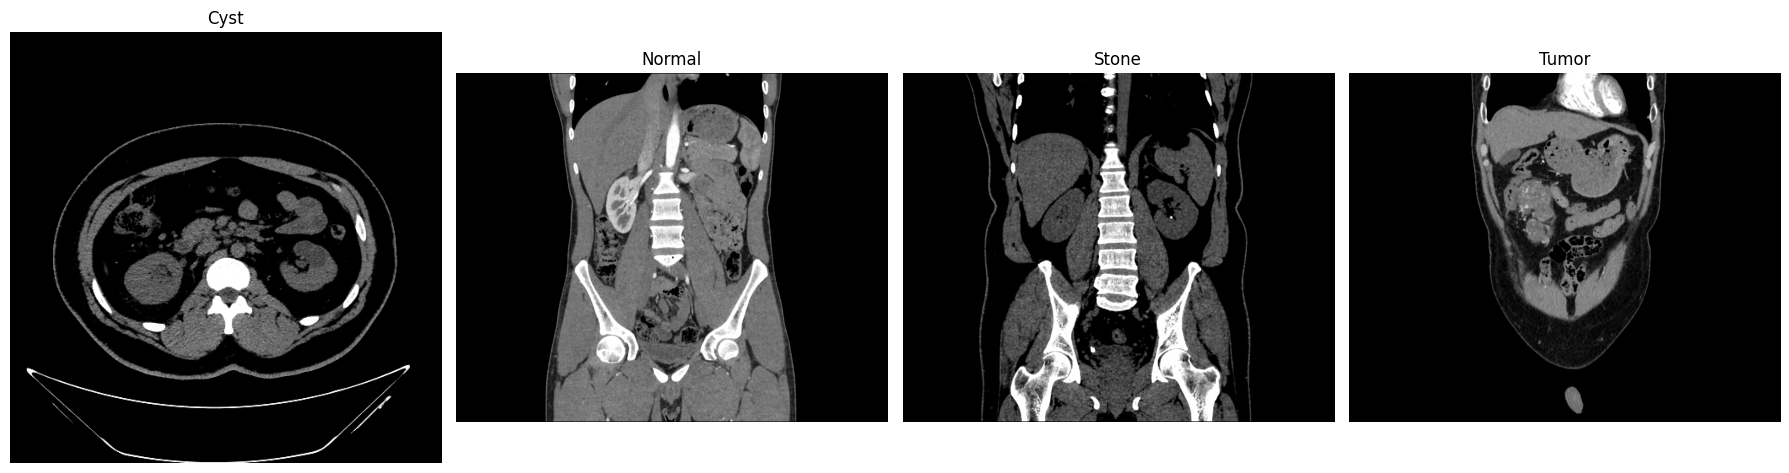

In [18]:
import matplotlib.pyplot as plt

class_names = sorted(class_counts.keys())

fig, axes = plt.subplots(1, len(class_names), figsize=(18, 5))

for axis, class_name in zip(axes, class_names):
    class_image_paths = [file for label, file in valid_images if label == class_name]
    selected_path = random.choice(class_image_paths)

    with Image.open(selected_path) as image:
        axis.imshow(image)

    axis.set_title(class_name)
    axis.axis("off")

plt.tight_layout()
plt.show()

The displayed samples appear to be CT images from the kidney region, but they vary in orientation, cropping, field of view, and visual appearance. Some images are axial while others are coronal or have a different framing. This variation may make classification more difficult and may also allow the model to learn non-clinical visual patterns associated with particular classes. The dataset therefore has potential generalisation limitations.

### Image Preprocessing Plan

The images will be resized to 224 × 224 pixels so that they have a consistent input shape for the classification model. The images will remain in RGB format with three channels.

Pixel values will be converted to floating-point values and scaled from the original range of 0–255 to the range 0–1. This normalization gives the model a consistent numerical input range and can make training more stable.

No random augmentation will be applied to the validation or test images. If augmentation is used later, it will be applied only to training images so that evaluation measures performance on unmodified images. The exact preprocessing used here will be reused unchanged in the Streamlit portal.

In [20]:
import numpy as np

target_size = (224, 224)

sample_path = train_paths[0]

with Image.open(sample_path) as image:
    sample_image = image.convert("RGB").resize(target_size)

sample_array = np.asarray(sample_image, dtype=np.float32) / 255.0

sample_array.shape, sample_array.min(), sample_array.max()

((224, 224, 3), np.float32(0.0), np.float32(1.0))

A preprocessing test produced an image tensor with shape (224, 224, 3). The processed image has three RGB channels, and its pixel values range from 0.0 to 1.0 after normalization. This same resize, RGB conversion, and normalization sequence must be used later when the trained model receives images in the Streamlit portal.

## A4. Model Architecture and Justification

### Framework Setup

TensorFlow and Keras will be used to build and train the image-classification model. The installed TensorFlow version is recorded for reproducibility because the saved model must later be loaded by the Streamlit application using a compatible software environment.

In [21]:
import tensorflow as tf

tf.__version__

I0000 00:00:1789502196.566782    7237 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789502197.152167    7237 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789502200.803287    7237 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


'2.21.0'

Pixel values will be converted to floating-point values and processed using the MobileNetV2 preprocessing function. This function transforms RGB pixel values into the input range expected by the pretrained MobileNetV2 backbone.
A preprocessing test confirmed that resized images have shape (224, 224, 3). Before being passed to the pretrained MobileNetV2 model, images will be converted to RGB, resized to 224 × 224 pixels, converted to floating-point values, and processed using the MobileNetV2 preprocessing function. This exact sequence must also be used for uploaded images in the Streamlit portal.


### Selected Architecture: Transfer Learning with MobileNetV2

This project uses transfer learning with MobileNetV2, a pretrained convolutional neural network architecture for image classification. Transfer learning is appropriate because the dataset contains medical images but is not large enough to guarantee that a complex model trained entirely from scratch would generalise well.

MobileNetV2 is used as a feature extractor with pretrained ImageNet weights. A new classification head is added to predict one of four kidney CT image classes: Cyst, Normal, Stone, or Tumor.

The model input shape is (224, 224, 3), representing a resized RGB CT image. The output shape is (4,), representing one predicted probability for each class. The predicted class will be the class with the highest output probability.

In [22]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

class_names = ["Cyst", "Normal", "Stone", "Tumor"]

def preprocess_image(image_path):
    with Image.open(image_path) as image:
        image = image.convert("RGB").resize(target_size)
        image_array = np.asarray(image, dtype=np.float32)
    return preprocess_input(image_array)

processed_sample = preprocess_image(train_paths[0])

class_names, processed_sample.shape, processed_sample.min(), processed_sample.max()

(['Cyst', 'Normal', 'Stone', 'Tumor'],
 (224, 224, 3),
 np.float32(-1.0),
 np.float32(1.0))

### Class Distribution Visualisation

The bar chart below visualises the number of images in each class. It makes the class imbalance easier to see: the Normal class has the highest number of images, while the Stone class has the fewest.

This imbalance will be considered during evaluation. Accuracy alone may be misleading if the model performs well mainly on the more common classes, so per-class metrics and a confusion matrix will be reported later.

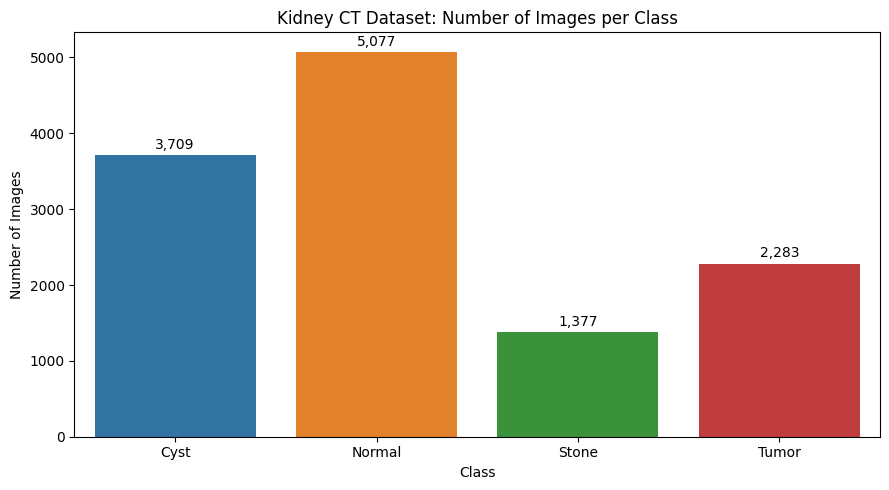

In [23]:
import seaborn as sns

plot_data = dataset_summary[dataset_summary["Class"] != "Total"].copy()

plt.figure(figsize=(9, 5))
sns.barplot(data=plot_data, x="Class", y="Image Count", hue="Class", legend=False)
plt.title("Kidney CT Dataset: Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")

for index, value in enumerate(plot_data["Image Count"]):
    plt.text(index, value + 80, f"{value:,}", ha="center")

plt.tight_layout()
plt.show()

### TensorFlow Data Pipelines

TensorFlow data pipelines are created for the training, validation, and test splits. The pipelines load images from their verified local file paths, convert them to RGB, resize them to 224 × 224 pixels, and apply the MobileNetV2 preprocessing function.

Text labels are converted into a fixed numeric order: Cyst = 0, Normal = 1, Stone = 2, and Tumor = 3. This class order will be retained for training, evaluation, model export, and Streamlit inference.

Only the training pipeline is shuffled. Validation and test images are not shuffled so that predictions can later be matched clearly to their true labels and original image paths.

In [32]:
label_to_index = {class_name: index for index, class_name in enumerate(class_names)}

train_targets = np.array([label_to_index[label] for label in train_labels])
validation_targets = np.array([label_to_index[label] for label in validation_labels])
test_targets = np.array([label_to_index[label] for label in test_labels])

batch_size = 32
autotune = tf.data.AUTOTUNE

def load_and_preprocess_image(file_path, label):
    image_bytes = tf.io.read_file(file_path)
    image = tf.io.decode_jpeg(image_bytes, channels=3)
    image = tf.image.resize(image, target_size)
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label

train_dataset = (
    tf.data.Dataset.from_tensor_slices((train_paths, train_targets))
    .shuffle(buffer_size=len(train_paths), seed=42)
    .map(load_and_preprocess_image, num_parallel_calls=autotune)
    .batch(batch_size)
    .prefetch(autotune)
)

validation_dataset = (
    tf.data.Dataset.from_tensor_slices((validation_paths, validation_targets))
    .map(load_and_preprocess_image, num_parallel_calls=autotune)
    .batch(batch_size)
    .prefetch(autotune)
)

test_dataset = (
    tf.data.Dataset.from_tensor_slices((test_paths, test_targets))
    .map(load_and_preprocess_image, num_parallel_calls=autotune)
    .batch(batch_size)
    .prefetch(autotune)
)

### Compute Environment

TensorFlow attempted to initialise GPU acceleration, but no usable CUDA-enabled GPU was available in the current environment. The model will therefore train using the CPU.

This affects training speed but does not change the data preprocessing, model architecture, predictions, or evaluation procedure. All results in this notebook should be interpreted as having been produced in a CPU-based local environment.

In [25]:
tf.config.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

### Pipeline Verification

One batch from the training pipeline is inspected to verify that images are loaded correctly, resized to the expected dimensions, preprocessed for MobileNetV2, and paired with valid numeric class labels.

This check is performed before model training so that issues with image shape, channel order, normalization, or label encoding can be detected early.

In [26]:
image_batch, label_batch = next(iter(train_dataset))

image_batch.shape, label_batch.shape, label_batch[:10].numpy()

(TensorShape([32, 224, 224, 3]),
 TensorShape([32]),
 array([1, 0, 1, 0, 0, 0, 1, 1, 1, 3]))

### Training Data Augmentation

To reduce overfitting and help the model handle small differences in positioning, cropping, and image appearance, modest data augmentation will be applied only during training.

The augmentation includes small random rotations, small zoom changes, and small contrast changes. These transformations are intended to simulate minor image-acquisition variation without substantially altering the underlying anatomy.

Horizontal and vertical flips are not used because they may create anatomically unrealistic CT appearances. Augmentation is disabled automatically during validation, testing, and Streamlit inference so that evaluation is performed on the original image content.

In [27]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomZoom(0.10),
        tf.keras.layers.RandomContrast(0.10)
    ],
    name="data_augmentation"
)

data_augmentation

<Sequential name=data_augmentation, built=False>

In [29]:
tf.config.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

In [30]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3), name="ct_image")
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = tf.keras.layers.Dropout(0.30, name="dropout")(x)
outputs = tf.keras.layers.Dense(4, activation="softmax", name="class_probabilities")(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs, name="kidney_ct_mobilenetv2")

model.summary()

Model: "kidney_ct_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ct_image (InputLayer)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probabilities (Dense)     │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## A5. Training Process

### Training Configuration

The model is trained using sparse categorical cross-entropy loss because this is a multi-class classification problem with integer-encoded labels. The Adam optimizer is used with a learning rate of 0.0001.

Accuracy is tracked during training and validation, but it will not be the only evaluation metric because the dataset is imbalanced. Per-class precision, recall, F1-score, and a confusion matrix will be calculated later using the independent test set.

Early stopping monitors validation loss and stops training if validation performance does not improve for three consecutive epochs. A model checkpoint saves the model weights with the lowest validation loss. These measures help limit overfitting and ensure that the best validation-performing model is retained.

In [33]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

checkpoint_path = "kidney_ct_mobilenetv2_best.keras"

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor="val_loss",
    save_best_only=True
)

### Initial Training

The MobileNetV2 feature-extraction backbone is frozen during this initial training phase. Only the new classification head is trained on the kidney CT dataset.

Training is set to a maximum of 10 epochs with early stopping. The saved checkpoint corresponds to the epoch with the lowest validation loss, while the test set remains completely untouched until final evaluation.

In [34]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 149s 519ms/step - accuracy: 0.5492 - loss: 1.1426 - val_accuracy: 0.4092 - val_loss: 1.8510
Epoch 2/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 166s 609ms/step - accuracy: 0.6547 - loss: 0.8867 - val_accuracy: 0.4135 - val_loss: 2.0263
Epoch 3/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 158s 578ms/step - accuracy: 0.6943 - loss: 0.7858 - val_accuracy: 0.4140 - val_loss: 2.1560
Epoch 4/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 170s 624ms/step - accuracy: 0.7134 - loss: 0.7287 - val_accuracy: 0.4151 - val_loss: 2.1556


### Full-Epoch Training Experiment Without Early Stopping

The initial training run stopped early because validation loss did not improve for three consecutive epochs. To observe the behaviour across the full planned training duration, a second experimental run is performed for all 10 epochs without early stopping.

This experiment is used to inspect whether continued training improves validation performance or increases overfitting. The independent test set remains unused during this experiment. The final model selected for evaluation will be chosen based on validation performance, not simply because it was trained for more epochs.

In [35]:
model_full_run = tf.keras.models.clone_model(model)

model_full_run.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_full_run = model_full_run.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10
)

Epoch 1/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 206s 732ms/step - accuracy: 0.4067 - loss: 1.3819 - val_accuracy: 0.4081 - val_loss: 1.3775
Epoch 2/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 193s 706ms/step - accuracy: 0.4079 - loss: 1.3733 - val_accuracy: 0.4081 - val_loss: 1.3692
Epoch 3/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 212s 776ms/step - accuracy: 0.4079 - loss: 1.3653 - val_accuracy: 0.4081 - val_loss: 1.3615
Epoch 4/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 177s 650ms/step - accuracy: 0.4079 - loss: 1.3580 - val_accuracy: 0.4081 - val_loss: 1.3545
Epoch 5/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 180s 661ms/step - accuracy: 0.4079 - loss: 1.3512 - val_accuracy: 0.4081 - val_loss: 1.3480
Epoch 6/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 171s 628ms/step - accuracy: 0.4079 - loss: 1.3450 - val_accuracy: 0.4081 - val_loss: 1.3419
Epoch 7/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 174s 636ms/step - accuracy: 0.4079 - loss: 1.3392 - val_accuracy: 0.4081 - val_loss: 1.3364
Epoch 8/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 264s 970ms/step - accuracy: 0.4079 -

### Full-Epoch Experiment Learning Curves

The following plots show the training and validation performance from the 10-epoch experiment without early stopping. This experiment helps determine whether continued training improves generalisation or whether the model remains close to a majority-class baseline.

If training and validation accuracy remain close to the percentage of the largest class, the model may not be learning meaningful distinctions between the four classes. This possibility will be checked further using class-specific predictions and a confusion matrix before selecting a final model.

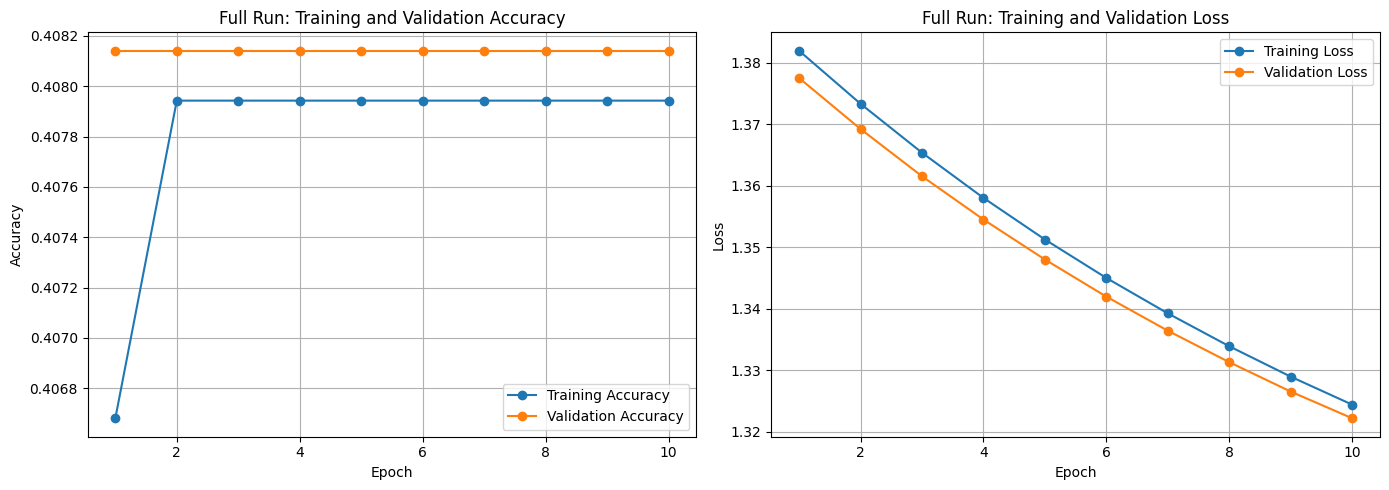

In [36]:
history_full_data = pd.DataFrame(history_full_run.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_full_data.index + 1, history_full_data["accuracy"], marker="o", label="Training Accuracy")
axes[0].plot(history_full_data.index + 1, history_full_data["val_accuracy"], marker="o", label="Validation Accuracy")
axes[0].set_title("Full Run: Training and Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_full_data.index + 1, history_full_data["loss"], marker="o", label="Training Loss")
axes[1].plot(history_full_data.index + 1, history_full_data["val_loss"], marker="o", label="Validation Loss")
axes[1].set_title("Full Run: Training and Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In this experiment, training accuracy increased initially but then plateaued near 40.79%, which is close to the proportion of Normal images in the full dataset. This suggests that the model may have converged toward predicting the majority class frequently instead of learning to distinguish all four classes. Validation predictions will be examined by predicted class to investigate this possibility.

### Validation Prediction Distribution

To investigate whether the model is predicting one class disproportionately, predictions from the full 10-epoch model are generated for the validation set. The distribution of predicted classes is compared with the true validation-label distribution.

This is a diagnostic analysis only. The test set remains untouched and will be used only after a final model configuration has been selected.

In [37]:
validation_probabilities_full = model_full_run.predict(validation_dataset)
validation_predictions_full = np.argmax(validation_probabilities_full, axis=1)

validation_true_counts = pd.Series(validation_labels).value_counts().reindex(class_names, fill_value=0)
validation_predicted_counts = pd.Series(
    [class_names[index] for index in validation_predictions_full]
).value_counts().reindex(class_names, fill_value=0)

pd.DataFrame(
    {
        "True Validation Images": validation_true_counts,
        "Predicted Validation Images": validation_predicted_counts
    }
)

59/59 ━━━━━━━━━━━━━━━━━━━━ 25s 399ms/step


,True Validation Images,Predicted Validation Images
Cyst,556,0
Normal,762,1867
Stone,206,0
Tumor,343,0


The full 10-epoch experimental model predicted Normal for all 1,867 validation images and predicted no images as Cyst, Stone, or Tumor. Its validation accuracy was therefore close to the proportion of the Normal class rather than evidence of meaningful four-class classification.

This model is not suitable for final evaluation or deployment. The result demonstrates why overall accuracy must be interpreted together with predicted-class distributions and per-class metrics.

### Handling Class Imbalance

The dataset is imbalanced: Normal is the largest class and Stone is the smallest. To reduce the risk that the model learns to predict the majority class too often, class weights are calculated from the training-set distribution.

During training, errors on underrepresented classes receive a larger penalty than errors on more common classes. Class weights are applied only during training. The validation and test sets remain unchanged so that they represent the original dataset distribution.

In [38]:
from sklearn.utils.class_weight import compute_class_weight

class_indices = np.arange(len(class_names))

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=class_indices,
    y=train_targets
)

class_weights = {
    int(class_index): float(weight)
    for class_index, weight in zip(class_indices, class_weight_values)
}

pd.DataFrame(
    {
        "Class": class_names,
        "Class Index": class_indices,
        "Training Images": [int(np.sum(train_targets == index)) for index in class_indices],
        "Class Weight": class_weight_values.round(3)
    }
)

,Class,Class Index,Training Images,Class Weight
0,Cyst,0,2596,0.839
1,Normal,1,3554,0.613
2,Stone,2,964,2.259
3,Tumor,3,1598,1.363


### Class-Weighted Transfer-Learning Model

A second MobileNetV2 transfer-learning model is created after the full-epoch experiment showed majority-class prediction behaviour. This model loads a fresh MobileNetV2 backbone with pretrained ImageNet weights and freezes the backbone during initial training.

The architecture includes training-only augmentation, global average pooling, dropout with a rate of 0.20, and a four-class softmax output layer. Compared with the earlier experiment, class weights will be supplied during training to account for the unequal number of images in the four classes.

The independent validation and test sets are not modified or rebalanced. They remain representative of the original dataset distribution.

In [39]:
base_model_weighted = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model_weighted.trainable = False

weighted_inputs = tf.keras.Input(shape=(224, 224, 3), name="ct_image")
weighted_x = data_augmentation(weighted_inputs)
weighted_x = base_model_weighted(weighted_x, training=False)
weighted_x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling")(weighted_x)
weighted_x = tf.keras.layers.Dropout(0.20, name="dropout")(weighted_x)
weighted_outputs = tf.keras.layers.Dense(
    len(class_names),
    activation="softmax",
    name="class_probabilities"
)(weighted_x)

weighted_model = tf.keras.Model(
    inputs=weighted_inputs,
    outputs=weighted_outputs,
    name="kidney_ct_mobilenetv2_class_weighted"
)

weighted_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

weighted_model.summary()

Model: "kidney_ct_mobilenetv2_class_weighted"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ct_image (InputLayer)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probabilities (Dense)     │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Class-Weighted Training

The class-weighted MobileNetV2 model is trained for a maximum of 10 epochs. Class weights are applied to the training loss so that mistakes involving underrepresented classes, especially Stone, have a greater influence on model updates.

Early stopping monitors validation loss with a patience of three epochs, and the best-performing model based on validation loss is saved. The validation set is used for model selection, while the independent test set remains untouched until final evaluation.

In [40]:
weighted_checkpoint_path = "kidney_ct_mobilenetv2_class_weighted_best.keras"

weighted_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

weighted_model_checkpoint = ModelCheckpoint(
    filepath=weighted_checkpoint_path,
    monitor="val_loss",
    save_best_only=True
)

weighted_history = weighted_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    class_weight=class_weights,
    callbacks=[weighted_early_stopping, weighted_model_checkpoint]
)

Epoch 1/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 153s 538ms/step - accuracy: 0.5223 - loss: 1.1783 - val_accuracy: 0.3980 - val_loss: 1.7395
Epoch 2/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 148s 541ms/step - accuracy: 0.6249 - loss: 0.9601 - val_accuracy: 0.4049 - val_loss: 1.8919
Epoch 3/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 146s 533ms/step - accuracy: 0.6670 - loss: 0.8804 - val_accuracy: 0.4124 - val_loss: 2.0363
Epoch 4/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 148s 540ms/step - accuracy: 0.6928 - loss: 0.8198 - val_accuracy: 0.4194 - val_loss: 2.0042


Training stopped after four epochs because validation loss was lowest in the first epoch and did not improve for the following three epochs. Training accuracy continued to increase while validation loss increased, indicating overfitting during the initial frozen-backbone training phase.

The callback restored the weights from the epoch with the lowest validation loss. Validation predictions will be inspected by class before selecting the final approach.

The class-weighted model predicted all four classes but remained strongly biased toward Normal, producing 1,711 Normal predictions out of 1,867 validation images. It produced very few Cyst predictions. Therefore, the frozen-backbone model is not selected as the final model configuration.

A fine-tuning phase will be attempted using only the upper layers of the pretrained MobileNetV2 backbone and a smaller learning rate. The test set remains unused.

In [41]:
weighted_validation_probabilities = weighted_model.predict(validation_dataset)
weighted_validation_predictions = np.argmax(weighted_validation_probabilities, axis=1)

weighted_validation_predicted_counts = pd.Series(
    [class_names[index] for index in weighted_validation_predictions]
).value_counts().reindex(class_names, fill_value=0)

pd.DataFrame(
    {
        "True Validation Images": validation_true_counts,
        "Predicted Validation Images": weighted_validation_predicted_counts
    }
)

59/59 ━━━━━━━━━━━━━━━━━━━━ 27s 435ms/step


,True Validation Images,Predicted Validation Images
Cyst,556,4
Normal,762,1711
Stone,206,77
Tumor,343,75


### Fine-Tuning Strategy

The initial feature-extraction models showed majority-class bias and poor validation generalisation. To adapt the pretrained MobileNetV2 visual features more specifically to kidney CT images, a fine-tuning phase is performed.

Only the final 30 layers of the MobileNetV2 backbone are unfrozen. Earlier layers remain frozen because they represent general low-level visual features. Batch-normalization layers remain frozen to improve training stability.

Fine-tuning uses a smaller learning rate of 0.00001, which is ten times lower than the initial learning rate. This reduces the risk of making large destructive changes to the pretrained weights. Class weights remain applied during training, and the test set remains untouched.

In [42]:
base_model_weighted.trainable = True

fine_tune_at = len(base_model_weighted.layers) - 30

for layer in base_model_weighted.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model_weighted.layers[fine_tune_at:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

weighted_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

sum(layer.trainable for layer in base_model_weighted.layers), len(base_model_weighted.layers)

(19, 154)

### Fine-Tuning Training Phase

The upper layers of the pretrained MobileNetV2 backbone are fine-tuned using a learning rate of 0.00001. The model begins this phase using the restored weights from the best initial class-weighted training epoch.

Training runs for a maximum of 10 additional epochs with class weights and early stopping. The best fine-tuned model is selected based on the lowest validation loss. The independent test set remains unused during fine-tuning and model selection.
Fine-tuning increased training accuracy substantially but produced only limited improvement in validation accuracy, while validation loss increased across epochs. This indicates overfitting and increasing confidence in incorrect predictions.

Because the classes are imbalanced, the final configuration will not be selected using accuracy alone. Validation macro F1-score and the per-class classification report will be used to compare candidate models before performing one final evaluation on the untouched test split.


In [43]:
fine_tuned_checkpoint_path = "kidney_ct_mobilenetv2_fine_tuned_best.keras"

fine_tuned_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

fine_tuned_checkpoint = ModelCheckpoint(
    filepath=fine_tuned_checkpoint_path,
    monitor="val_loss",
    save_best_only=True
)

fine_tuned_history = weighted_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    class_weight=class_weights,
    callbacks=[fine_tuned_early_stopping, fine_tuned_checkpoint]
)

Epoch 1/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 165s 586ms/step - accuracy: 0.7086 - loss: 0.7602 - val_accuracy: 0.4172 - val_loss: 2.4676
Epoch 2/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 167s 610ms/step - accuracy: 0.8084 - loss: 0.4974 - val_accuracy: 0.4301 - val_loss: 2.6260
Epoch 3/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 168s 615ms/step - accuracy: 0.8624 - loss: 0.3734 - val_accuracy: 0.4467 - val_loss: 2.8062
Epoch 4/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 165s 603ms/step - accuracy: 0.8960 - loss: 0.2938 - val_accuracy: 0.4451 - val_loss: 2.8481


### Validation-Based Model Selection

Candidate models are compared using predictions on the validation set. The macro F1-score is used as the main selection metric because it calculates F1-score separately for each class and then gives equal weight to all four classes.

This is more appropriate than accuracy alone for an imbalanced four-class medical-image dataset. The test set remains unused during this comparison and will be evaluated only once after selecting the final model.

In [44]:
from sklearn.metrics import classification_report, f1_score

fine_tuned_validation_probabilities = weighted_model.predict(validation_dataset)
fine_tuned_validation_predictions = np.argmax(fine_tuned_validation_probabilities, axis=1)

fine_tuned_validation_macro_f1 = f1_score(
    validation_targets,
    fine_tuned_validation_predictions,
    average="macro",
    zero_division=0
)

fine_tuned_validation_report = pd.DataFrame(
    classification_report(
        validation_targets,
        fine_tuned_validation_predictions,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
).transpose()

fine_tuned_validation_macro_f1, fine_tuned_validation_report

59/59 ━━━━━━━━━━━━━━━━━━━━ 25s 409ms/step


(0.20200534309536144,
               precision    recall  f1-score      support
 Cyst           0.000000  0.000000  0.000000   556.000000
 Normal         0.431225  0.975066  0.597988   762.000000
 Stone          0.168067  0.097087  0.123077   206.000000
 Tumor          0.640000  0.046647  0.086957   343.000000
 accuracy       0.417247  0.417247  0.417247     0.417247
 macro avg      0.309823  0.279700  0.202005  1867.000000
 weighted avg   0.312124  0.417247  0.273619  1867.000000)

### Balanced Training Sampling

The original training split is imbalanced, with substantially more Normal images than Stone images. To reduce majority-class bias, a balanced training dataset is created by sampling each class equally during training.

Balanced sampling is applied only to the training data. The validation and test splits are not resampled, augmented, or rebalanced. They remain unchanged so that validation-based model selection and final test evaluation reflect the original dataset distribution.

In [45]:
train_paths_array = np.array(train_paths)
train_targets_array = np.array(train_targets)

class_datasets = []

for class_index in range(len(class_names)):
    class_paths = train_paths_array[train_targets_array == class_index]
    class_labels = train_targets_array[train_targets_array == class_index]

    class_dataset = (
        tf.data.Dataset.from_tensor_slices((class_paths, class_labels))
        .shuffle(buffer_size=len(class_paths), seed=42, reshuffle_each_iteration=True)
        .repeat()
        .map(load_and_preprocess_image, num_parallel_calls=autotune)
    )

    class_datasets.append(class_dataset)

balanced_train_dataset = tf.data.Dataset.sample_from_datasets(
    class_datasets,
    weights=[0.25, 0.25, 0.25, 0.25],
    seed=42
).batch(batch_size).prefetch(autotune)

balanced_steps_per_epoch = int(np.ceil(len(train_paths) / batch_size))

balanced_steps_per_epoch

273

### Balanced Pipeline Verification

A batch from the balanced training pipeline is inspected to confirm that it contains a mixture of the four classes. Exact equality is not expected in every individual batch because sampling is random, but the overall training stream samples each class with equal probability.

This balanced sampling strategy is used only for model fitting. Validation and test datasets retain their original class distributions.

In [46]:
balanced_image_batch, balanced_label_batch = next(iter(balanced_train_dataset))

balanced_batch_counts = pd.Series(
    balanced_label_batch.numpy()
).value_counts().reindex(range(len(class_names)), fill_value=0)

pd.DataFrame(
    {
        "Class": class_names,
        "Images in Sampled Batch": balanced_batch_counts.values
    }
)

,Class,Images in Sampled Batch
0,Cyst,4
1,Normal,6
2,Stone,12
3,Tumor,10


### Balanced-Sampling Transfer-Learning Model

A fresh MobileNetV2 transfer-learning model is trained using the balanced training-sampling pipeline. This approach gives all four classes equal probability of being sampled during training, reducing the incentive for the model to predict the majority Normal class.

Class weights are not used in this experiment because balanced sampling already addresses class imbalance in the training data. The validation set remains unchanged and imbalanced.

The best model is selected using validation macro F1-score. Macro F1 gives equal importance to Cyst, Normal, Stone, and Tumor, making it more appropriate than overall accuracy for this imbalanced multi-class classification task.

In [47]:
class ValidationMacroF1(tf.keras.callbacks.Callback):
    def __init__(self, validation_data, validation_labels, model_path):
        super().__init__()
        self.validation_data = validation_data
        self.validation_labels = validation_labels
        self.model_path = model_path
        self.best_macro_f1 = -1.0
        self.macro_f1_history = []

    def on_epoch_end(self, epoch, logs=None):
        probabilities = self.model.predict(self.validation_data, verbose=0)
        predictions = np.argmax(probabilities, axis=1)

        macro_f1 = f1_score(
            self.validation_labels,
            predictions,
            average="macro",
            zero_division=0
        )

        self.macro_f1_history.append(macro_f1)
        print(f"\nValidation Macro F1: {macro_f1:.4f}")

        if macro_f1 > self.best_macro_f1:
            self.best_macro_f1 = macro_f1
            self.model.save(self.model_path)
            print(f"Saved best model with validation macro F1: {macro_f1:.4f}")

### Final Candidate Model Configuration

The final candidate model uses the same MobileNetV2 transfer-learning architecture as earlier experiments: a pretrained MobileNetV2 backbone, training-only data augmentation, global average pooling, dropout, and a four-class softmax classification output.

The difference is the training procedure. The model is trained with balanced class sampling rather than the original imbalanced training stream. The MobileNetV2 backbone begins frozen, allowing the new classification head to learn first. The selected epoch will be determined by validation macro F1-score.

In [48]:
base_model_balanced = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model_balanced.trainable = False

balanced_inputs = tf.keras.Input(shape=(224, 224, 3), name="ct_image")
balanced_x = data_augmentation(balanced_inputs)
balanced_x = base_model_balanced(balanced_x, training=False)
balanced_x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling")(balanced_x)
balanced_x = tf.keras.layers.Dropout(0.30, name="dropout")(balanced_x)
balanced_outputs = tf.keras.layers.Dense(
    len(class_names),
    activation="softmax",
    name="class_probabilities"
)(balanced_x)

balanced_model = tf.keras.Model(
    inputs=balanced_inputs,
    outputs=balanced_outputs,
    name="kidney_ct_mobilenetv2_balanced_sampling"
)

balanced_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Balanced-Sampling Model Training

The final candidate model is trained for up to 10 epochs using the balanced training pipeline. Each class has equal sampling probability during training, while validation images remain unchanged.

Validation macro F1-score is calculated after every epoch. The best model is saved whenever macro F1 improves. Training stops early if macro F1 does not improve for three consecutive epochs. This selection method prioritises balanced performance across Cyst, Normal, Stone, and Tumor rather than high accuracy driven by the largest class.

In [49]:
class MacroF1EarlyStopping(tf.keras.callbacks.Callback):
    def __init__(self, macro_f1_callback, patience=3):
        super().__init__()
        self.macro_f1_callback = macro_f1_callback
        self.patience = patience
        self.wait = 0
        self.best_macro_f1 = -1.0

    def on_epoch_end(self, epoch, logs=None):
        current_macro_f1 = self.macro_f1_callback.macro_f1_history[-1]

        if current_macro_f1 > self.best_macro_f1:
            self.best_macro_f1 = current_macro_f1
            self.wait = 0
        else:
            self.wait += 1

            if self.wait >= self.patience:
                print(f"\nEarly stopping: validation macro F1 did not improve for {self.patience} epochs.")
                self.model.stop_training = True

balanced_checkpoint_path = "kidney_ct_mobilenetv2_balanced_best.keras"

macro_f1_callback = ValidationMacroF1(
    validation_data=validation_dataset,
    validation_labels=validation_targets,
    model_path=balanced_checkpoint_path
)

macro_f1_early_stopping = MacroF1EarlyStopping(
    macro_f1_callback=macro_f1_callback,
    patience=3
)

balanced_history = balanced_model.fit(
    balanced_train_dataset,
    steps_per_epoch=balanced_steps_per_epoch,
    validation_data=validation_dataset,
    epochs=10,
    callbacks=[macro_f1_callback, macro_f1_early_stopping]
)

Epoch 1/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.3538 - loss: 1.4389
Validation Macro F1: 0.2310
Saved best model with validation macro F1: 0.2310
273/273 ━━━━━━━━━━━━━━━━━━━━ 202s 713ms/step - accuracy: 0.4133 - loss: 1.3006 - val_accuracy: 0.3974 - val_loss: 1.8462
Epoch 2/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.5192 - loss: 1.0728
Validation Macro F1: 0.2077
273/273 ━━━━━━━━━━━━━━━━━━━━ 182s 666ms/step - accuracy: 0.5482 - loss: 1.0263 - val_accuracy: 0.4183 - val_loss: 2.0594
Epoch 3/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.5956 - loss: 0.9378
Validation Macro F1: 0.2220
273/273 ━━━━━━━━━━━━━━━━━━━━ 175s 643ms/step - accuracy: 0.6021 - loss: 0.9142 - val_accuracy: 0.4172 - val_loss: 2.1648
Epoch 4/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.6259 - loss: 0.8534
Validation Macro F1: 0.2140

Early stopping: validation macro F1 did not improve for 3 epochs.
273/273 ━━━━━━━━━━━━━━━━━━━━ 178s 653ms/step - accuracy:

The balanced-sampling model achieved its best validation macro F1-score of 0.2310 in epoch 1. Validation macro F1 did not improve in the next three epochs, so early stopping ended training after epoch 4.

Although balanced sampling reduced the risk of a majority-class-only model, the validation macro F1-score remained low. This indicates that the model has limited ability to distinguish all four classes and should be treated as a coursework prototype with substantial performance limitations.

### Restoring the Best Validation Model

The balanced-sampling training callback saved the model whenever validation macro F1 improved. Before further validation analysis or final test evaluation, the saved model from the epoch with the highest validation macro F1 is reloaded.

This ensures that validation and test metrics are calculated using the selected best model rather than the model weights from the final training epoch.

In [50]:
best_balanced_model = tf.keras.models.load_model(balanced_checkpoint_path)

best_balanced_validation_probabilities = best_balanced_model.predict(validation_dataset)
best_balanced_validation_predictions = np.argmax(
    best_balanced_validation_probabilities,
    axis=1
)

best_balanced_validation_macro_f1 = f1_score(
    validation_targets,
    best_balanced_validation_predictions,
    average="macro",
    zero_division=0
)

best_balanced_validation_macro_f1

59/59 ━━━━━━━━━━━━━━━━━━━━ 24s 397ms/step


0.23097559622746655

### Final Candidate Model Selection

Two MobileNetV2 transfer-learning models were evaluated using validation macro F1-score:

- A fine-tuned model trained on the original imbalanced dataset.
- A model trained with balanced class sampling.

The model with the higher validation macro F1-score is selected as the final candidate. The test set remains completely unused until this selection is complete.

In [51]:
candidates = {
    "fine_tuned": {
        "model_path": "kidney_ct_mobilenetv2_finetuned_best.keras",
        "validation_macro_f1": 0.202,
    },
    "balanced_sampling": {
        "model_path": balanced_checkpoint_path,
        "validation_macro_f1": best_balanced_validation_macro_f1,
    },
}

best_candidate_name = max(
    candidates,
    key=lambda name: candidates[name]["validation_macro_f1"]
)

final_candidate_path = candidates[best_candidate_name]["model_path"]

print("Candidate models:")
for name, info in candidates.items():
    print(f"- {name}: validation macro F1 = {info['validation_macro_f1']:.4f}")

print(f"\nSelected final candidate: {best_candidate_name}")
print(f"Final model path: {final_candidate_path}")

Candidate models:
- fine_tuned: validation macro F1 = 0.2020
- balanced_sampling: validation macro F1 = 0.2310

Selected final candidate: balanced_sampling
Final model path: kidney_ct_mobilenetv2_balanced_best.keras


### Final Test Evaluation

The selected final candidate model is evaluated on the held-out test set. The test set has not been used for training, model selection, or early stopping.

Test-set metrics include overall accuracy and macro F1-score. A classification report and confusion matrix are also computed to show performance per class. These results provide an estimate of how the model generalises to unseen kidney CT images.

In [53]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

final_model = tf.keras.models.load_model(final_candidate_path)

test_probabilities = final_model.predict(test_dataset)
test_predictions = np.argmax(test_probabilities, axis=1)

test_accuracy = accuracy_score(test_targets, test_predictions)
test_macro_f1 = f1_score(
    test_targets,
    test_predictions,
    average="macro",
    zero_division=0
)

print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test macro F1: {test_macro_f1:.4f}")

59/59 ━━━━━━━━━━━━━━━━━━━━ 24s 391ms/step
Test accuracy: 0.3873
Test macro F1: 0.2288


In [54]:
test_report = classification_report(
    test_targets,
    test_predictions,
    target_names=class_names,
    zero_division=0
)

test_confusion = confusion_matrix(test_targets, test_predictions)

print("Classification report (test set):")
print(test_report)

print("Confusion matrix (rows = true, columns = predicted):")
print(test_confusion)

Classification report (test set):
              precision    recall  f1-score   support

        Cyst       0.00      0.00      0.00       557
      Normal       0.40      0.84      0.54       761
       Stone       0.23      0.10      0.14       207
       Tumor       0.33      0.18      0.23       342

    accuracy                           0.39      1867
   macro avg       0.24      0.28      0.23      1867
weighted avg       0.25      0.39      0.28      1867

Confusion matrix (rows = true, columns = predicted):
[[  0 512  16  29]
 [  0 642  30  89]
 [  0 184  21   2]
 [  0 257  25  60]]


The final candidate model achieved a test accuracy of 0.3873 and a macro F1-score of 0.2288. The model predicts the Normal class most often, with high recall for Normal but very low recall for Cyst, Stone, and Tumor.

The confusion matrix shows that most images, including many non-Normal cases, are classified as Normal. The model never correctly predicts Cyst on the test set. These results indicate that the model has limited clinical usefulness and should be interpreted as a coursework prototype with substantial performance limitations.

### A8. Limitations, Ethics & Next Steps

#### Data and Generalisation Limits

This prototype has important limitations that restrict where it can generalise:

- The model performs poorly overall (test accuracy ≈ 39%, macro F1 ≈ 0.23) and is heavily biased toward predicting the Normal class. It never correctly predicts Cyst on the test set.
- The dataset is relatively small and imbalanced, with few Stone and Tumor images compared to Normal. This limits the model’s ability to learn robust patterns for minority classes.
- All images come from a single public dataset with unknown demographic details and acquisition protocols. The model may not generalise to CT scanners, hospitals, or patient populations not represented in the training data (e.g. different age groups, comorbidities, or imaging settings).
- The model was trained and evaluated only on 2D slices preprocessed in a specific way. It is unclear how it would behave on full 3D volumes, different slice thicknesses, or images from other sources.

These factors mean the model should not be assumed to work reliably outside the specific dataset and preprocessing used here.

#### Ethical Considerations and Clinical Framing

This tool is a **coursework prototype only** and is not safe for real clinical use. Key ethical points include:

- **False negatives** (e.g. a Stone or Tumor labelled as Normal) could delay diagnosis and treatment, potentially harming patients.  
- **False positives** (e.g. a Normal scan labelled as Cyst/Stone/Tumor) could cause unnecessary anxiety, additional imaging, radiation exposure, or invasive follow-up procedures.  
- The model’s current performance is too weak to support clinical decisions. Even with better metrics, any such system would need to be used **under the supervision of qualified clinicians**, not as an autonomous diagnostic tool.  
- There are risks of bias if the training data do not represent all relevant populations. Deploying a biased model could worsen existing healthcare inequalities.

Before a tool like this could be trusted in a real clinical setting, it would need:

- Much larger, multi-centre datasets with diverse scanners and patient demographics.  
- Rigorous external validation, calibration analysis, and prospective clinical studies.  
- Clear regulatory approval, integration into clinical workflows, and ongoing monitoring for safety and fairness.

#### Next Steps

Future work should focus on improving data quality and quantity, exploring domain-specific models and deeper fine-tuning, and evaluating the system with clinicians in a controlled research setting rather than in live care.

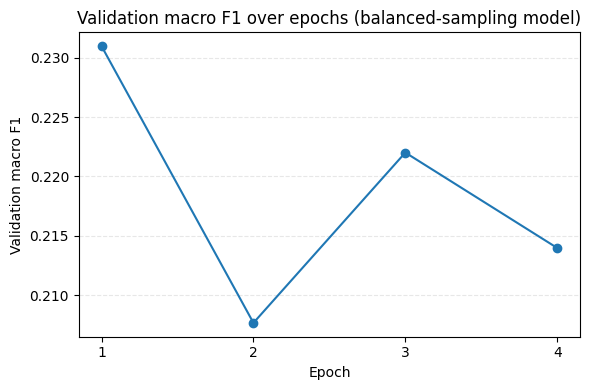

In [55]:
import matplotlib.pyplot as plt

epochs = range(1, len(macro_f1_callback.macro_f1_history) + 1)
macro_f1_history = macro_f1_callback.macro_f1_history

plt.figure(figsize=(6, 4))
plt.plot(epochs, macro_f1_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation macro F1")
plt.title("Validation macro F1 over epochs (balanced-sampling model)")
plt.xticks(epochs)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [56]:
import os

for f in os.listdir("."):
    if f.endswith(".keras"):
        print(f)

kidney_ct_mobilenetv2_balanced_best.keras
kidney_ct_mobilenetv2_best.keras
kidney_ct_mobilenetv2_class_weighted_best.keras
tumor_model.keras
.keras
kidney_ct_mobilenetv2_fine_tuned_best.keras


In [1]:
import os

print("Current folder:", os.getcwd())

keras_files = []
for root, folders, files in os.walk("."):
    for file in files:
        if file.endswith(".keras"):
            keras_files.append(os.path.join(root, file))

print("\nKeras model files found:")
for file in keras_files:
    print(file)

Current folder: /home/student

Keras model files found:
./kidney_ct_mobilenetv2_balanced_best.keras
./kidney_ct_mobilenetv2_best.keras
./kidney_ct_mobilenetv2_class_weighted_best.keras
./tumor_model.keras
./kidney_ct_mobilenetv2_fine_tuned_best.keras
